# Vision Transformer-Based Student Engagement Recognition in Online

**Group Members:** Ghulam Mustafa (Fa-2022/BSCS/188) & Faizan Ali (Fa-2022/BSCS/187)  

**Objective:** Fine-tune a pre-trained Swin Transformer to classify student engagement into 3 categories: Highly Engaged, Moderately Engaged, and Disengaged, aiming to match or exceed 88.73% accuracy.

**About:** This notebook implements a student engagement detection system using the Swin Transformer architecture. We map 6 sub-categories into 3 main classes (Highly Engaged, Moderately Engaged, Disengaged) to compare results with the original research paper.

### Install and Import Libraries

In [1]:
!pip install -q transformers torchvision scikit-learn matplotlib seaborn tqdm

In [2]:
import os
import shutil
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from transformers import SwinForImageClassification, get_scheduler
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch.optim as optim
from tqdm.auto import tqdm
from torchvision.datasets import DatasetFolder
from PIL import Image

## Dataset Restructuring

In [3]:
original_dir = '/kaggle/input/datasets/deepramazumder/student-engagement-dataset/Student-engagement-dataset'
custom_dir = '/kaggle/input/datasets/mustafaxgm/custom-student-engagement-video-frame-dataset/engagement_dataset'
target_dir = '/kaggle/working/Dataset_3_Classes'

### Define the mapping

In [4]:
mapping = {
    'Highly_Engaged': [
        'Engaged/Focused'
    ],
    'Moderately_Engaged': [
        'Engaged/Confused',
        'Engaged/Frustrated'
    ],
    'Disengaged': [
        'Not Engaged/Bored',
        'Not Engaged/Drowsy',
        'Not Engaged/Looking Away'
    ]
}

In [5]:
custom_mapping = {
    'Highly_Engaged': ['highly_engaged'],
    'Moderately_Engaged': ['moderately_engaged'],
    'Disengaged': ['disengaged']
}

In [6]:
def restructure_dataset(src, dst, mapping):
    os.makedirs(dst, exist_ok=True)
    total_copied = 0
    
    for class_name, subfolders in mapping.items():
        class_path = os.path.join(dst, class_name)
        os.makedirs(class_path, exist_ok=True)
        
        for sub in subfolders:
            sub_src_path = os.path.normpath(os.path.join(src, sub)) 
            
            if os.path.exists(sub_src_path):
                files_in_dir = os.listdir(sub_src_path)
                valid_files = [f for f in files_in_dir if not f.startswith('.')] 
                
                print(f"📂 Found '{sub}' -> Copying {len(valid_files)} files to {class_name}...")
                
                for img in valid_files:
                    try:
                        safe_prefix = sub.replace('/', '_').replace('\\', '_').replace(' ', '')
                        new_filename = f"{safe_prefix}_{img}"
                        
                        src_file = os.path.join(sub_src_path, img)
                        dst_file = os.path.join(class_path, new_filename)
                        
                        shutil.copy(src_file, dst_file)
                        total_copied += 1
                    except Exception as e:
                        print(f"   ❌ Error copying {img}: {e}")
                
    print(f"\n✅ Total images successfully copied AND RENAMED: {total_copied}")

In [7]:
print("Restructuring Original Dataset...")
restructure_dataset(original_dir, target_dir, mapping)

print("\nRestructuring Custom Dataset...")
restructure_dataset(custom_dir, target_dir, custom_mapping)

print("\nRestructuring complete!")

Restructuring Original Dataset...
📂 Found 'Engaged/Focused' -> Copying 347 files to Highly_Engaged...
📂 Found 'Engaged/Confused' -> Copying 369 files to Moderately_Engaged...
📂 Found 'Engaged/Frustrated' -> Copying 360 files to Moderately_Engaged...
📂 Found 'Not Engaged/Bored' -> Copying 358 files to Disengaged...
📂 Found 'Not Engaged/Drowsy' -> Copying 263 files to Disengaged...
📂 Found 'Not Engaged/Looking Away' -> Copying 423 files to Disengaged...

✅ Total images successfully copied AND RENAMED: 2120

Restructuring Custom Dataset...
📂 Found 'highly_engaged' -> Copying 348 files to Highly_Engaged...
📂 Found 'moderately_engaged' -> Copying 389 files to Moderately_Engaged...
📂 Found 'disengaged' -> Copying 387 files to Disengaged...

✅ Total images successfully copied AND RENAMED: 1124

Restructuring complete!


_____________

## Data Loading & Augmentation

### 1. Define separate transforms (Augment Train, keep Test static)

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify() 
        return True
    except Exception:
        return False

print("Scanning all files and forcing PyTorch to load them (this may take a few seconds)...")

Scanning all files and forcing PyTorch to load them (this may take a few seconds)...


### 2. Load the dataset twice

In [10]:
dataset_train = DatasetFolder(
    root=target_dir,
    loader=datasets.folder.default_loader,
    is_valid_file=is_valid_image,
    transform=train_transform
)

dataset_test = DatasetFolder(
    root=target_dir,
    loader=datasets.folder.default_loader,
    is_valid_file=is_valid_image,
    transform=test_transform
)

print(f"Total images forced into PyTorch: {len(dataset_train)}")
print(f"Classes mapping: {dataset_train.class_to_idx}")

Total images forced into PyTorch: 3244
Classes mapping: {'Disengaged': 0, 'Highly_Engaged': 1, 'Moderately_Engaged': 2}


### 3. Calculate split sizes (70%, 15%, 15%)

In [11]:
total_size = len(dataset_train)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

### 4. Generate random indices

In [12]:
generator = torch.Generator().manual_seed(42)
train_idx, val_idx, test_idx = random_split(
    range(total_size), [train_size, val_size, test_size], generator=generator
)

### 5. Create Subsets explicitly assigning the correct dataset/transform

In [13]:
train_data = Subset(dataset_train, train_idx)
val_data = Subset(dataset_test, val_idx)   
test_data = Subset(dataset_test, test_idx)

### 6. Build Loaders

In [14]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
print(f"Data Split -> Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Data Split -> Train: 2270 | Val: 486 | Test: 488


_______________

## Model Initialization

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

Training on device: cuda


In [16]:
model_name = "microsoft/swin-base-patch4-window7-224-in22k"
print(f"Loading Model: {model_name}...")

model = SwinForImageClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True 
)
model = model.to(device)

Loading Model: microsoft/swin-base-patch4-window7-224-in22k...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/437M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-base-patch4-window7-224-in22k
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([21841]) vs model:torch.Size([3])            
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([21841, 1024]) vs model:torch.Size([3, 1024])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


#### Loss and Optimizer (using AdamW with weight decay, as specified in the paper)

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

print("Model successfully loaded and modified for 3 classes!")

Model successfully loaded and modified for 3 classes!


__________

## Training Loop

In [18]:
from tqdm.auto import tqdm

In [19]:
# Setup Early Stopping parameters
epochs = 50          
patience = 5         
patience_counter = 0 
best_val_acc = 0.0

In [20]:
print(f"Starting training for up to {epochs} epochs with a patience of {patience}...")

Starting training for up to 50 epochs with a patience of 5...


#### Loop:

In [21]:
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-" * 15)
    
    # -- Training Phase --
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    # tqdm adds a nice progress bar for the training batches
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_loss = running_loss / len(train_data)
    train_acc = correct / total
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    
    # -- Validation Phase --
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs.logits, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.logits, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_epoch_loss = val_loss / len(val_data)
    val_epoch_acc = val_correct / val_total
    print(f"Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}")
    
    # -- Early Stopping Logic --
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        torch.save(model.state_dict(), 'best_swin_model.pth')
        print("🌟 Validation improved! New best model saved.")
        patience_counter = 0 
    else:
        patience_counter += 1
        print(f"⚠️ No improvement. Patience: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print("\n🛑 Early Stopping Triggered! The model has fully converged.")
            break


Epoch 1/50
---------------


Training:   0%|          | 0/71 [00:00<?, ?it/s]

Train Loss: 0.3555 | Train Acc: 0.8454
Val Loss: 0.2236 | Val Acc: 0.9074
🌟 Validation improved! New best model saved.

Epoch 2/50
---------------


Training:   0%|          | 0/71 [00:00<?, ?it/s]

Train Loss: 0.1200 | Train Acc: 0.9568
Val Loss: 0.1014 | Val Acc: 0.9568
🌟 Validation improved! New best model saved.

Epoch 3/50
---------------


...

Train Loss: 0.0337 | Train Acc: 0.9881
Val Loss: 0.0454 | Val Acc: 0.9815
⚠️ No improvement. Patience: 3/5

Epoch 14/50
---------------


Training:   0%|          | 0/71 [00:00<?, ?it/s]

Train Loss: 0.0056 | Train Acc: 0.9991
Val Loss: 0.0215 | Val Acc: 0.9897
⚠️ No improvement. Patience: 4/5

Epoch 15/50
---------------


Training:   0%|          | 0/71 [00:00<?, ?it/s]

Train Loss: 0.0145 | Train Acc: 0.9952
Val Loss: 0.1232 | Val Acc: 0.9712
⚠️ No improvement. Patience: 5/5

🛑 Early Stopping Triggered! The model has fully converged.


___________

## Evaluation

In [22]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from tqdm.auto import tqdm

In [23]:
print("Loading the best model weights...")
model.load_state_dict(torch.load('best_swin_model.pth'))
model.eval()

all_preds = []
all_labels = []

print("Running final evaluation on the unseen Test Set...")

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluating"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        _, predicted = torch.max(outputs.logits, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Loading the best model weights...
Running final evaluation on the unseen Test Set...


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

### Calculate Metrics:

In [24]:
accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
print("\n" + "="*30)
print("MODEL METRICS:")
print("\n" + "="*30)
print(f"OVERALL ACCURACY:    {accuracy * 100:.2f}%")
print(f"MACRO PRECISION:     {macro_precision * 100:.2f}%")
print(f"MACRO RECALL:        {macro_recall * 100:.2f}%")
print(f"MACRO F1-SCORE:      {macro_f1 * 100:.2f}%")
print(f"WEIGHTED F1-SCORE:   {weighted_f1 * 100:.2f}%")
print("="*30 + "\n")


MODEL METRICS:

OVERALL ACCURACY:    99.59%
MACRO PRECISION:     99.68%
MACRO RECALL:        99.61%
MACRO F1-SCORE:      99.64%
WEIGHTED F1-SCORE:   99.59%



#### Classification Report

In [25]:
target_names = ['Disengaged', 'Highly_Engaged', 'Moderately_Engaged'] 
print("DETAILED CLASSIFICATION REPORT:")
print("\n" + "="*60)
print(classification_report(all_labels, all_preds, target_names=target_names))
print("\n" + "="*60)

DETAILED CLASSIFICATION REPORT:

                    precision    recall  f1-score   support

        Disengaged       0.99      1.00      1.00       208
    Highly_Engaged       1.00      1.00      1.00       109
Moderately_Engaged       1.00      0.99      0.99       171

          accuracy                           1.00       488
         macro avg       1.00      1.00      1.00       488
      weighted avg       1.00      1.00      1.00       488




___________

## Visualization

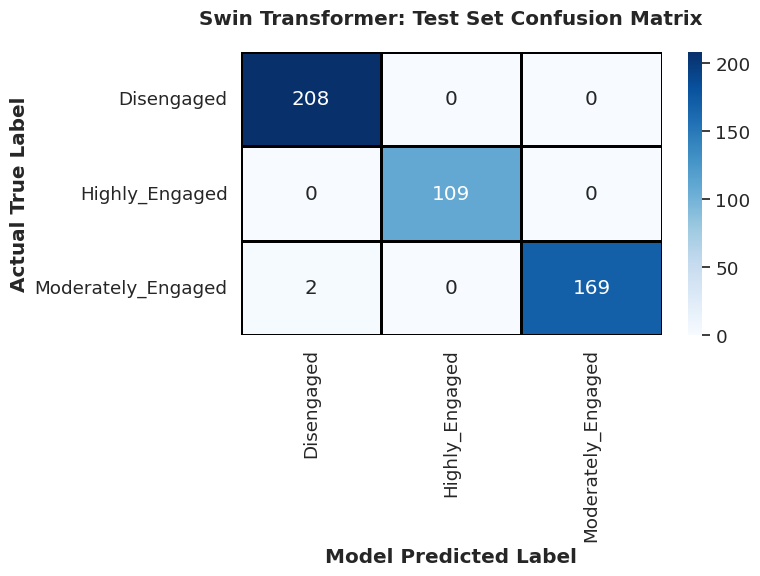

In [26]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid", font_scale=1.2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names,
            linewidths=1, linecolor='black')

plt.title('Swin Transformer: Test Set Confusion Matrix', pad=20, fontweight='bold')
plt.ylabel('Actual True Label', fontweight='bold')
plt.xlabel('Model Predicted Label', fontweight='bold')
plt.tight_layout()

# Save the image for your report
plt.savefig('confusion_matrix_for_report.png', dpi=300)
plt.show()

Fetching a random batch of test images...
Generating visual grid...


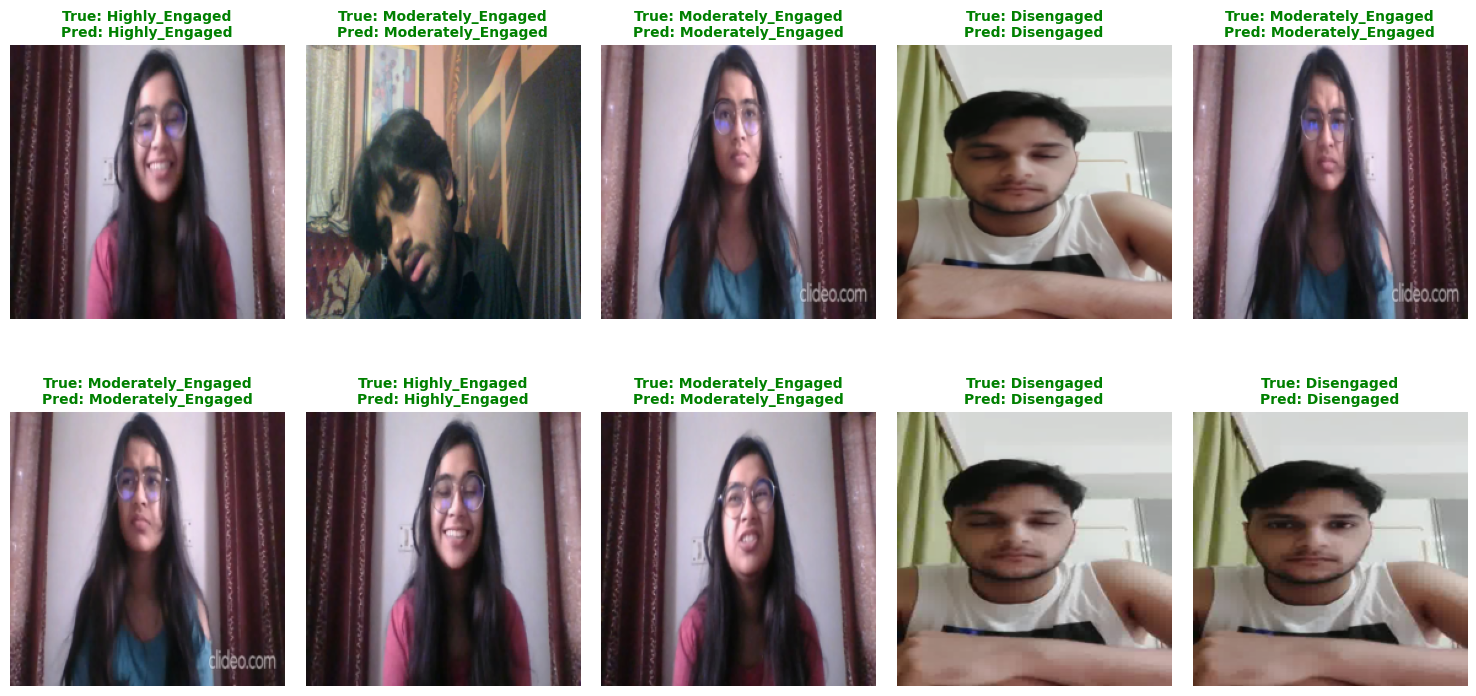

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def imshow(inp, title=None, color='black'):
    """Utility function to un-normalize and display an image"""
    inp = inp.numpy().transpose((1, 2, 0))
    # Undo the normalization we applied in Step 3
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # Ensure pixel values are valid
    
    plt.imshow(inp)
    if title is not None:
        plt.title(title, color=color, fontweight='bold', fontsize=10)
    plt.axis('off')

print("Fetching a random batch of test images...")
# Get one batch of test data
inputs, labels = next(iter(test_loader))
inputs = inputs.to(device)

# Run the model to get predictions
with torch.no_grad():
    outputs = model(inputs)
    _, preds = torch.max(outputs.logits, 1)

# Set up the plot
fig = plt.figure(figsize=(15, 8))
target_names = ['Disengaged', 'Highly_Engaged', 'Moderately_Engaged'] 

print("Generating visual grid...")

# Display the first 10 images from the batch
for idx in range(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    
    true_label = target_names[labels[idx].item()]
    pred_label = target_names[preds[idx].item()]
    
    # Color text green if correct, red if wrong
    title_color = 'green' if preds[idx] == labels[idx] else 'red'
    title_text = f"True: {true_label}\nPred: {pred_label}"
    
    imshow(inputs.cpu().data[idx], title=title_text, color=title_color)

plt.tight_layout()

# Save the image for your report!
plt.savefig('prediction_grid_for_report.png', dpi=300, bbox_inches='tight')
plt.show()

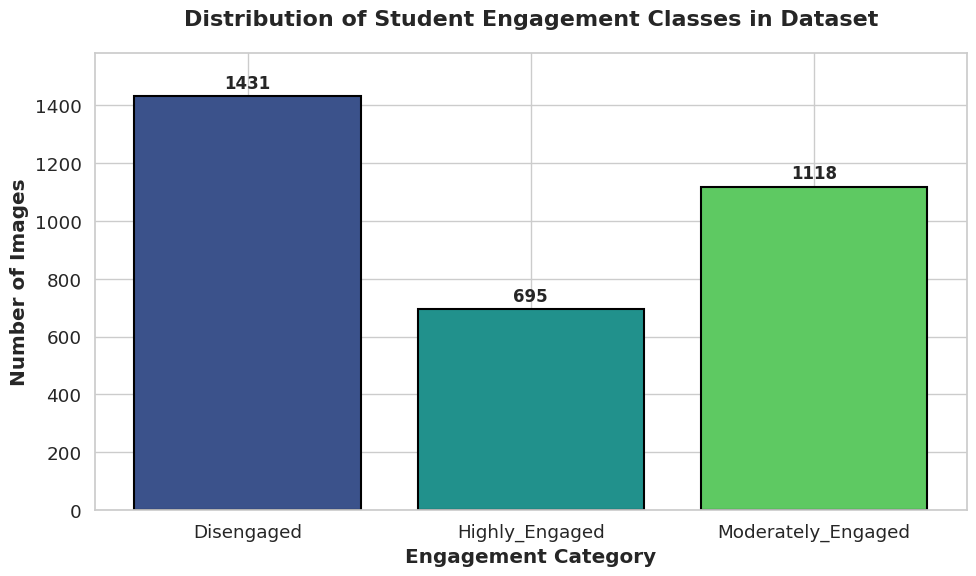

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

class_counts = Counter([label for _, label in dataset_train.samples])
target_names = ['Disengaged', 'Highly_Engaged', 'Moderately_Engaged'] 

counts = [class_counts[i] for i in range(len(target_names))]

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", font_scale=1.2)
colors = sns.color_palette("viridis", len(target_names))
bars = plt.bar(target_names, counts, color=colors, edgecolor='black', linewidth=1.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 15, int(yval), 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Distribution of Student Engagement Classes in Dataset', pad=20, fontweight='bold', fontsize=16)
plt.ylabel('Number of Images', fontweight='bold')
plt.xlabel('Engagement Category', fontweight='bold')
plt.ylim(0, max(counts) + 150) # Give some headroom for the text
plt.tight_layout()

plt.savefig('class_distribution_for_report.png', dpi=300)
plt.show()

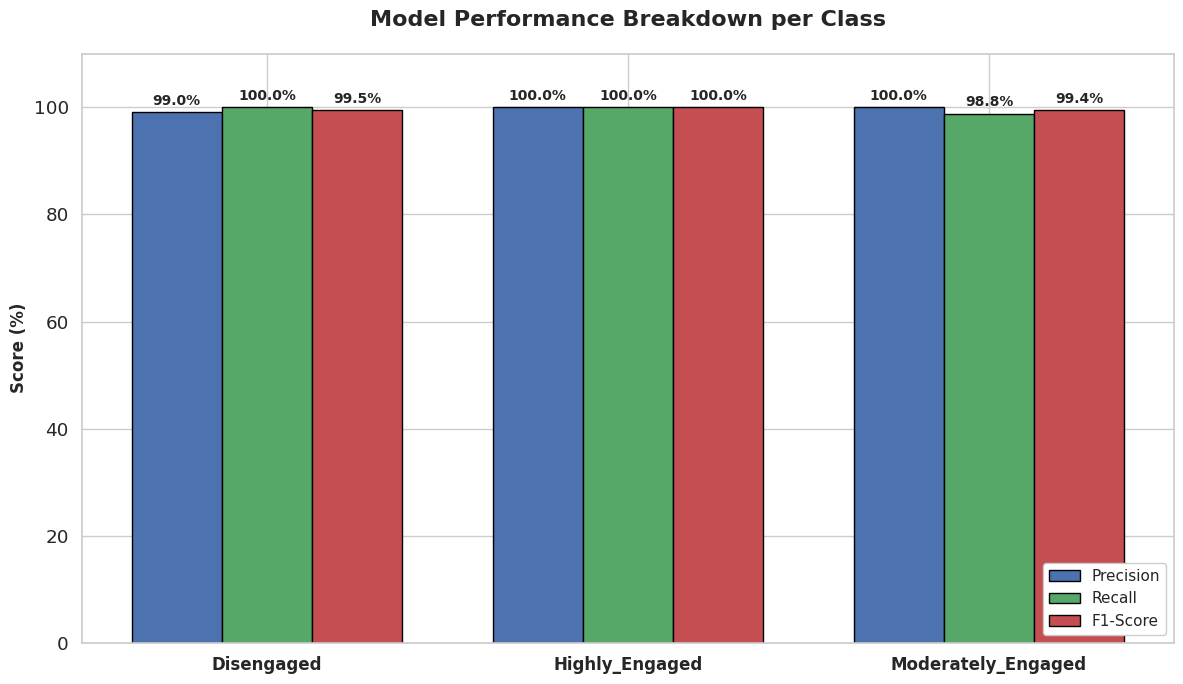

In [29]:
# --- STEP 9: Per-Class Metrics Visualization ---
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds)
target_names = ['Disengaged', 'Highly_Engaged', 'Moderately_Engaged'] 
x = np.arange(len(target_names))  # the label locations
width = 0.25  # the width of the bars
fig, ax = plt.subplots(figsize=(12, 7))
sns.set_theme(style="whitegrid")

rects1 = ax.bar(x - width, precision * 100, width, label='Precision', color='#4C72B0', edgecolor='black')
rects2 = ax.bar(x, recall * 100, width, label='Recall', color='#55A868', edgecolor='black')
rects3 = ax.bar(x + width, f1 * 100, width, label='F1-Score', color='#C44E52', edgecolor='black')

ax.set_ylabel('Score (%)', fontweight='bold', fontsize=12)
ax.set_title('Model Performance Breakdown per Class', pad=20, fontweight='bold', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(target_names, fontweight='bold', fontsize=12)
ax.legend(loc='lower right', framealpha=1).set_zorder(10)
ax.set_ylim(0, 110) # Set max Y to 110 to fit the legend/text

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.savefig('per_class_metrics_for_report.png', dpi=300)
plt.show()

_____________________

## Final Comparison & Exports

In [30]:
import pandas as pd

#### 1. Create a Comparison Table

In [31]:
results_data = {
    "Metric": ["Accuracy", "Macro F1-Score"],
    "Research Paper (E-ViT)": ["88.73%", "87.56%"],
    "Our Implementation (Swin-Base)": [f"{accuracy*100:.2f}%", f"{macro_f1*100:.2f}%"]
}

comparison_df = pd.DataFrame(results_data)

print("FINAL COMPARISON TABLE")
print("="*30)
print(comparison_df)
print("="*30)

FINAL COMPARISON TABLE
           Metric Research Paper (E-ViT) Our Implementation (Swin-Base)
0        Accuracy                 88.73%                         99.59%
1  Macro F1-Score                 87.56%                         99.64%


#### 2. Export the Comparison to CSV for your Report

In [32]:
comparison_df.to_csv('final_comparison_results.csv', index=False)

#### 3. Final Model Serialization

In [33]:
torch.save(model, 'full_engagement_model.pth')

print("\nNotebook Complete!")
print("Files saved for report: confusion_matrix.png, prediction_grid.png, class_distribution.png, final_comparison_results.csv")


Notebook Complete!
Files saved for report: confusion_matrix.png, prediction_grid.png, class_distribution.png, final_comparison_results.csv
